# DTEx211. Recognizing MNIST Digits

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx211_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

This example trains a fully connected neural network to identify handwritten digits using the MNIST dataset.

In [2]:
import deeptrack as dt
import numpy as np
import matplotlib.pyplot as plt
import torch

/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.10/Python
  Referenced from: <0F9D4B2E-DD75-3BAC-BD55-6FA98E65FDBD> /opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.10/Python' (no such file)
  import torch_geometric.typing
/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. St

## 1. Downloading the MNIST Dataset

Start by downloading the MNIST dataset.

The MNIST dataset consists of grayscale images of hand-written digits from 0 to 9. Each image is 28 pixels by 28 pixels. There're 60,000 training images and 10,000 test images.

You will download it from the GitHub repository https://github.com/DeepTrackAI/MNIST_dataset, where the MNIST images are organized in two folders named `train` and `test`:

> train/0_000000.png<br>
> train/0_000001.png<br>
> ...<br>
> train/1_000000.png<br>
> ...<br>

> test/0_000000.png<br>
> ...<br>
> test/1_000000.png<br>
> ...<br>

The first digit in the filename is the label.

In [3]:
import os

target_dir = os.path.join("datasets", "MNIST")

if not os.path.isdir(target_dir):
    os.system(
        f"git clone https://github.com/DeepTrackAI/MNIST_dataset {target_dir}"
    )

train_path = os.path.join(target_dir, "mnist", "train")
test_path = os.path.join(target_dir, "mnist", "test")

Cloning into 'datasets/MNIST'...
Updating files: 100% (70003/70003), done.


## 2. Loading the Training Dataset

The dataset is how you provide the network with training data. For this example, you will create the dataset by loading it from storage using the `LoadImage` class.

Start by creating an `ImageFolder` object to hold the list of files corresponding to the training images.

In [5]:
train_files = dt.sources.ImageFolder(train_path)

print(f"Dataset contains {len(train_files)} train images")

Dataset contains 60000 train images


Then, create a pipeline that loads the normalized images and another one that loads the corresponding digit.

In [6]:
# Pipeline to load the images.
train_image = (
    dt.LoadImage(path=train_files.path)
    >> dt.NormalizeMinMax(0, 1)  # Normalize the image to [0, 1]
    >> dt.MoveAxis(2, 0)  # Move the color channel to the first axis
    >> dt.pytorch.ToTensor(dtype=torch.float32)  # Convert to a PyTorch tensor
)

# Pipeline to load the labels.
train_digit = (
    dt.Value(train_files.label_name[0])  # Get the first digit of the name
    >> int  # Convert the digit to an integer
    >> np.array  # Convert to a NumPy array
    >> dt.pytorch.ToTensor(dtype=torch.long)  # Convert to a PyTorch tensor
)

Finally, combine them into a single dataset that returns a tuple with an MNIST image and the corresponding ground-truth digit value.

In [7]:
train_dataset = dt.pytorch.Dataset(
    train_image & train_digit,
    train_files,
)

You can now plot some example images.

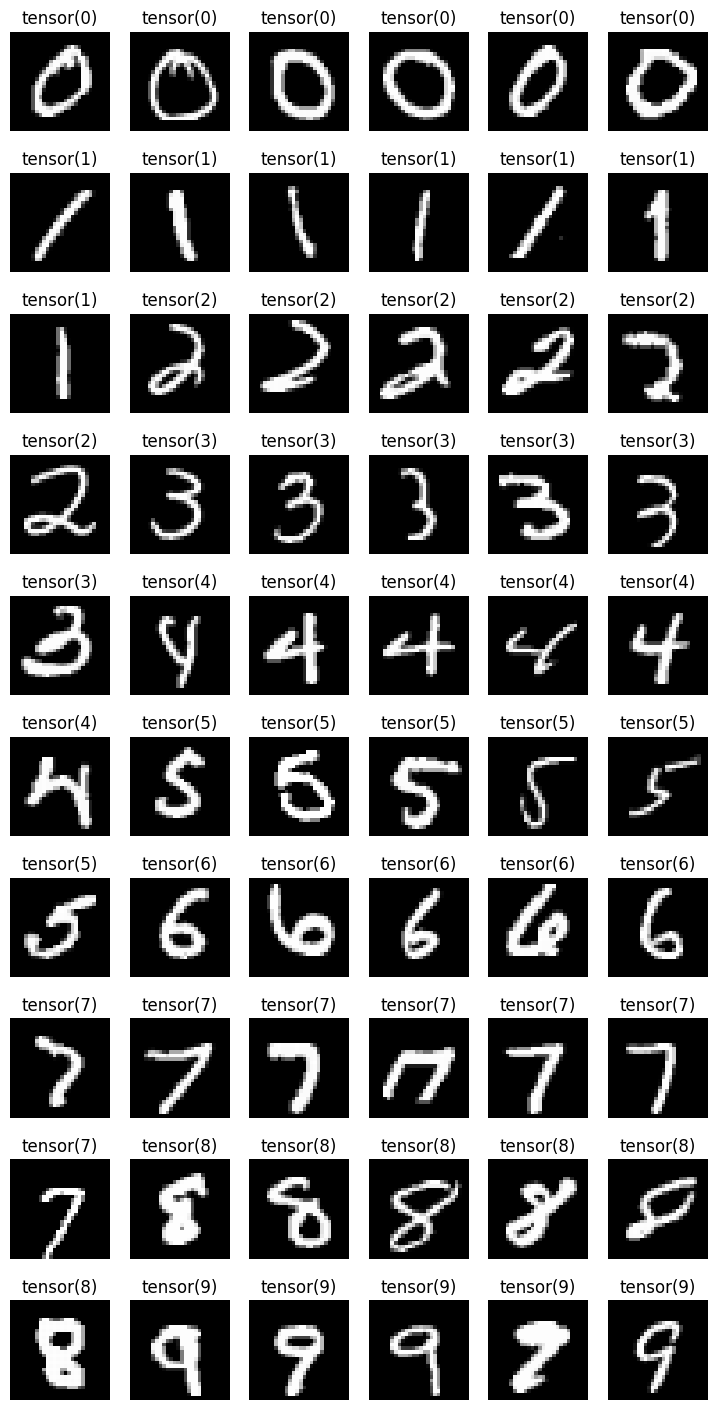

In [8]:
fig, axs = plt.subplots(10, 6, figsize=(9, 18))

for i, ax in enumerate(axs.flatten()):
    image, digit = train_dataset[i * 1_000]
    ax.imshow(image.numpy().squeeze(), cmap="gray")
    ax.set_title(digit)
    ax.axis("off")

### 2.1. Loading the Validation Dataset

You can follow similar steps to load the validation dataset.

In [9]:
test_files = dt.sources.ImageFolder(test_path)

print(f"Dataset contains {len(test_files)} test images")

test_image = (
    dt.LoadImage(path=test_files.path)
    >> dt.NormalizeMinMax(0, 1)
    >> dt.MoveAxis(2, 0)
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)
test_digit = (
    dt.Value(test_files.label_name[0])
    >> int
    >> np.array
    >> dt.pytorch.ToTensor(dtype=torch.long)
)

test_dataset = dt.pytorch.Dataset(test_image & test_digit, test_files)

Dataset contains 10000 test images


## 3. Augmenting the Training Set

In order to expand the dataset, you will augment it with affine and elastic augmentations.

Affine augmentations consist of translating, rescaling, rotating, and shearing.

In [10]:
# How much to scale in x and y.
scale = (
    lambda: 0.8 + np.random.rand() * 0.4,
    lambda: 0.8 + np.random.rand() * 0.4,
)

translate_px = (
    lambda: int(np.random.randint(-2, 3)),
    lambda: int(np.random.randint(-2, 3)),
)


# Dummy property: whether to rotate or shear.
should_rotate = lambda: np.random.randint(2)

# If should rotate, how much.
rotate = lambda should_rotate: (-0.35 + np.random.rand() * 0.7) * should_rotate

# If not should rotate, how much shear.
shear = lambda should_rotate: (
    (-0.35 + np.random.rand() * 0.7) * (1 - should_rotate)
)

affine_transform = dt.Affine(
    scale=scale,
    translate_px=translate_px,
    should_rotate=should_rotate,
    shear=shear,
    order=2,
    mode="constant",
)

Elastic augmentations distort the image elastically.

In [11]:
# Amplitude of distortions.
alpha = lambda: np.random.rand() * 60

# Granularity of distortions.
sigma = lambda: 5 + np.random.rand() * 2

# Last dimension is not a channel, so it should be augmented too.
ignore_last_dim = True

elastic_transform = dt.ElasticTransformation(
    alpha=alpha,
    sigma=sigma,
    ignore_last_dim=ignore_last_dim,
    mode="constant",
)

Finally, since these distortions may cause pixels to fall outside the range of (0, 1), you need to clip the values.

In [12]:
clip = dt.Clip(0, 1)

You can now add the augmentations to the pipeline.

By setting `replace=True`, you ensure that the images of the digits are replaced in each epoch of the training.

In [13]:
augmentation = affine_transform >> elastic_transform >> clip

augmented_train_image = (
    dt.LoadImage(path=train_files.path)
    >> dt.NormalizeMinMax(0, 1)
    >> augmentation  # Apply the augmentation
    >> dt.MoveAxis(2, 0)
    >> dt.pytorch.ToTensor(dtype=torch.float32)
)

augmented_train_dataset = dt.pytorch.Dataset(
    augmented_train_image & train_digit,
    train_files,
    replace=True,
)

augmented_train_dataset[i]

(tensor([[[0.0000e+00, 0.0000e+00, 2.2755e-09, 0.0000e+00, 0.0000e+00,
           1.8465e-07, 0.0000e+00, 9.9005e-06, 0.0000e+00, 2.6818e-04,
           0.0000e+00, 3.5995e-03, 0.0000e+00, 0.0000e+00, 2.6916e-01,
           8.5703e-01, 9.2640e-01, 1.6151e-01, 0.0000e+00, 1.2260e-02,
           0.0000e+00, 2.0752e-04, 0.0000e+00, 4.4157e-05, 0.0000e+00,
           1.7192e-06, 0.0000e+00, 1.0470e-09],
          [0.0000e+00, 3.3689e-11, 2.6611e-09, 0.0000e+00, 3.7905e-08,
           2.4449e-07, 0.0000e+00, 2.1499e-05, 0.0000e+00, 5.0488e-04,
           0.0000e+00, 8.2839e-03, 0.0000e+00, 1.7337e-01, 8.7030e-01,
           1.0000e+00, 8.3184e-01, 2.9822e-01, 2.4746e-03, 3.2186e-03,
           0.0000e+00, 1.1449e-03, 0.0000e+00, 0.0000e+00, 1.8073e-05,
           0.0000e+00, 2.1658e-07, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 5.2022e-09, 1.7591e-08, 0.0000e+00,
           7.9092e-07, 1.5271e-06, 0.0000e+00, 4.0931e-04, 0.0000e+00,
           1.0101e-02, 0.0000e+00, 4.2010e-02, 6.626

To ensure the data and the labels match up, plot some images and print their corresponding label.

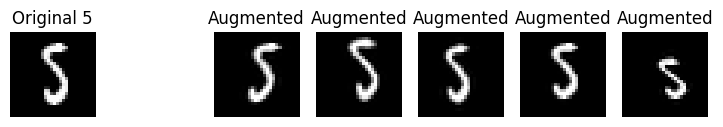

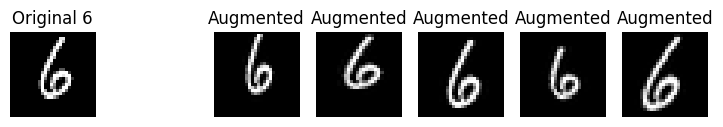

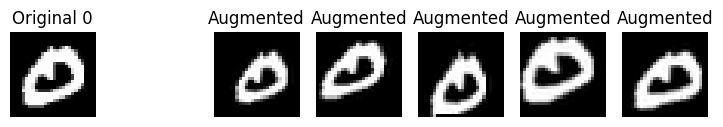

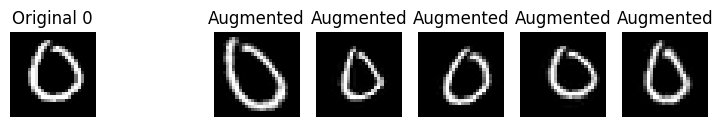

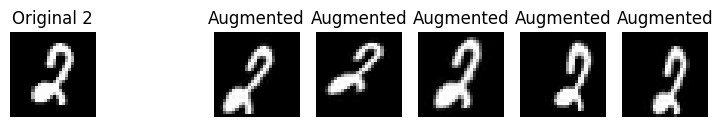

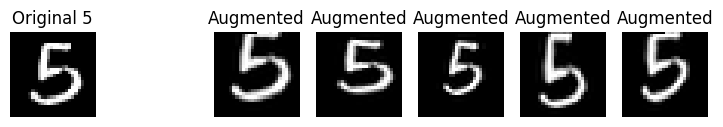

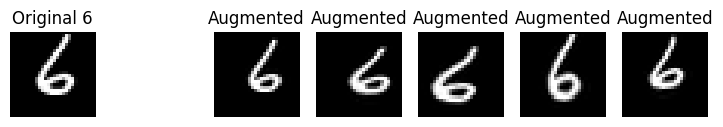

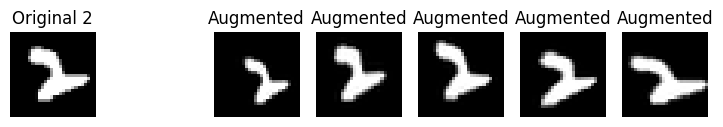

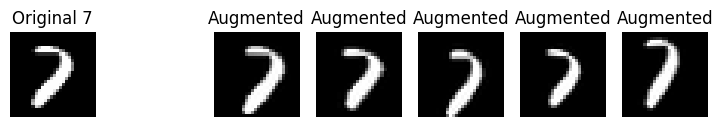

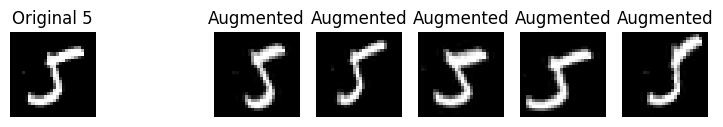

In [14]:
for _ in range(10):
    plt.figure(figsize=(9, 2))

    # Select the index of the image to augment.
    i = np.random.randint(len(train_files))

    # Get the original image and digit.
    original_image, digit = train_dataset[i]

    plt.subplot(1, 7, 1)
    plt.imshow(original_image.numpy().squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Original {digit}")

    for sub_plt in range(3, 8):

        # Get the augmented image.
        augmentation.update()
        augmented_image, _ = augmented_train_dataset[i]

        plt.subplot(1, 7, sub_plt)
        plt.imshow(augmented_image.numpy().squeeze(), cmap="gray")
        plt.axis("off")
        plt.title("Augmented")

    plt.show()

You can set `replace=.1` (or another number between 0 and 1) to achieve a tradeoff between diversity of the training set and computational speed.

In [15]:
augmented_train_dataset = dt.pytorch.Dataset(
    augmented_train_image & train_digit,
    train_files,
    replace=0.1,
)

## 4. Defining the Network

The network used is a fully connected neural network.

First, you define the network architecture.

In [16]:
import deeptrack.deeplay as dl

mlp_template = dl.MultiLayerPerceptron(
    in_features=28 * 28,
    hidden_features=[128, 128, 64, 64],
    out_features=10,
)
for block in mlp_template.blocks:
    block.append(dl.Layer(torch.nn.Dropout, 0.1))
mlp_template[..., "activation#-1"].configure(torch.nn.Softmax, dim=-1)
mlp = mlp_template.create()

print(mlp)

MultiLayerPerceptron(
  (blocks): LayerList(
    (0): LinearBlock(
      (layer): Linear(in_features=784, out_features=128, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): LinearBlock(
      (layer): Linear(in_features=128, out_features=128, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): LinearBlock(
      (layer): Linear(in_features=128, out_features=64, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (3): LinearBlock(
      (layer): Linear(in_features=64, out_features=64, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (4): LinearBlock(
      (layer): Linear(in_features=64, out_features=10, bias=True)
      (activation): Softmax(dim=-1)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
)


Then, you compile the network, defining the loss function and the optimizer.

In [17]:
classifier_template = dl.Classifier(
    model=mlp,
    num_classes=10,
    make_targets_one_hot=True,
    optimizer=dl.RMSprop(lr=0.001),
)
classifier = classifier_template.create()

print(classifier)

Classifier(
  (loss): CrossEntropyLoss()
  (optimizer): RMSprop[RMSprop](lr=0.001)
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=784, out_features=128, bias=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): LinearBlock(
        (layer): Linear(in_features=128, out_features=128, bias=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (2): LinearBlock(
        (layer): Linear(in_features=128, out_features=64, bias=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (3

/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


## 5. Training the Network

You can now train the network.

First define the data loaders for the training and validation data.

In [18]:
train_dataloader = torch.utils.data.DataLoader(
    augmented_train_dataset,
    batch_size=32,
    shuffle=True,
)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
)

Finally, you can proceed with the training.

The training process can be slow on some machines because the augmented images are regenerated every time they are accessed, rather than precomputed and reused. You can reduce `max_epochs` to shorten the total training time, decrease the `replace` parameter used in the dataset to trade off augmentation diversity for speed, or increase `num_workers` in the data loaders above to parallelize data loading and augmentation across CPU cores.

In [19]:
trainer = dl.Trainer(
    max_epochs=10,
    accelerator="auto",
)

trainer.fit(
    classifier,
    train_dataloader,
    test_dataloader,
)

/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss     │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │     0 │
│ 4 │ model         │ MultiLayerPerceptron │  130 K │ train │     0 │
│ 5 │ optimizer     │ RMSprop              │      0 │ train │     0 │
└───┴───────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 130 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 130 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                                                                            …

/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/gu_ml_base_feature2/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

You can plot the history of the losses and metrics during the training process.

(0.0, 1.0)

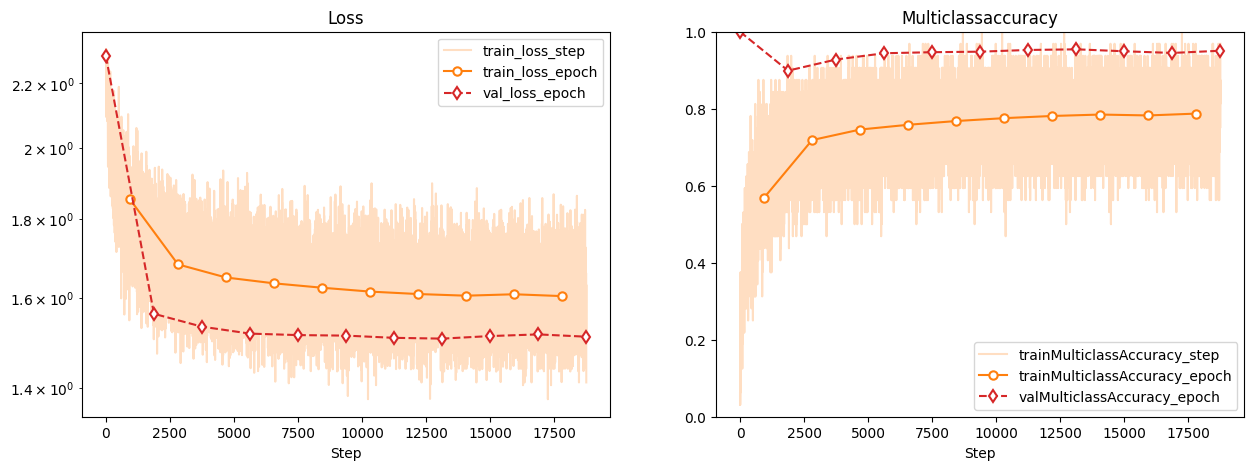

In [20]:
fig, axes = trainer.history.plot()
axes[1].set_yscale("linear")
axes[1].set_ylim(0.0, 1.0)

## 6. Evaluating the Training

You can now proceed to evaluate the quality of the training.

To do so, you need first to switch the `classifier` to evaluation mode (for example, to switch off the dropout layers).

In [21]:
classifier.eval()

Classifier(
  (loss): CrossEntropyLoss()
  (optimizer): RMSprop[RMSprop](lr=0.001, params=<generator object Module.parameters at 0x33282df50>)
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=784, out_features=128, bias=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): LinearBlock(
        (layer): Linear(in_features=128, out_features=128, bias=True)
        (activation): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (2): LinearBlock(
        (layer): Linear(in_features=128, out_features=64, bias=True)
        (activation): ReLU()
     

### 6.1. Comparing Ground-truth and Predicted Digits

You can show a few images wirth the corresponding the true digit and the predicted digit.

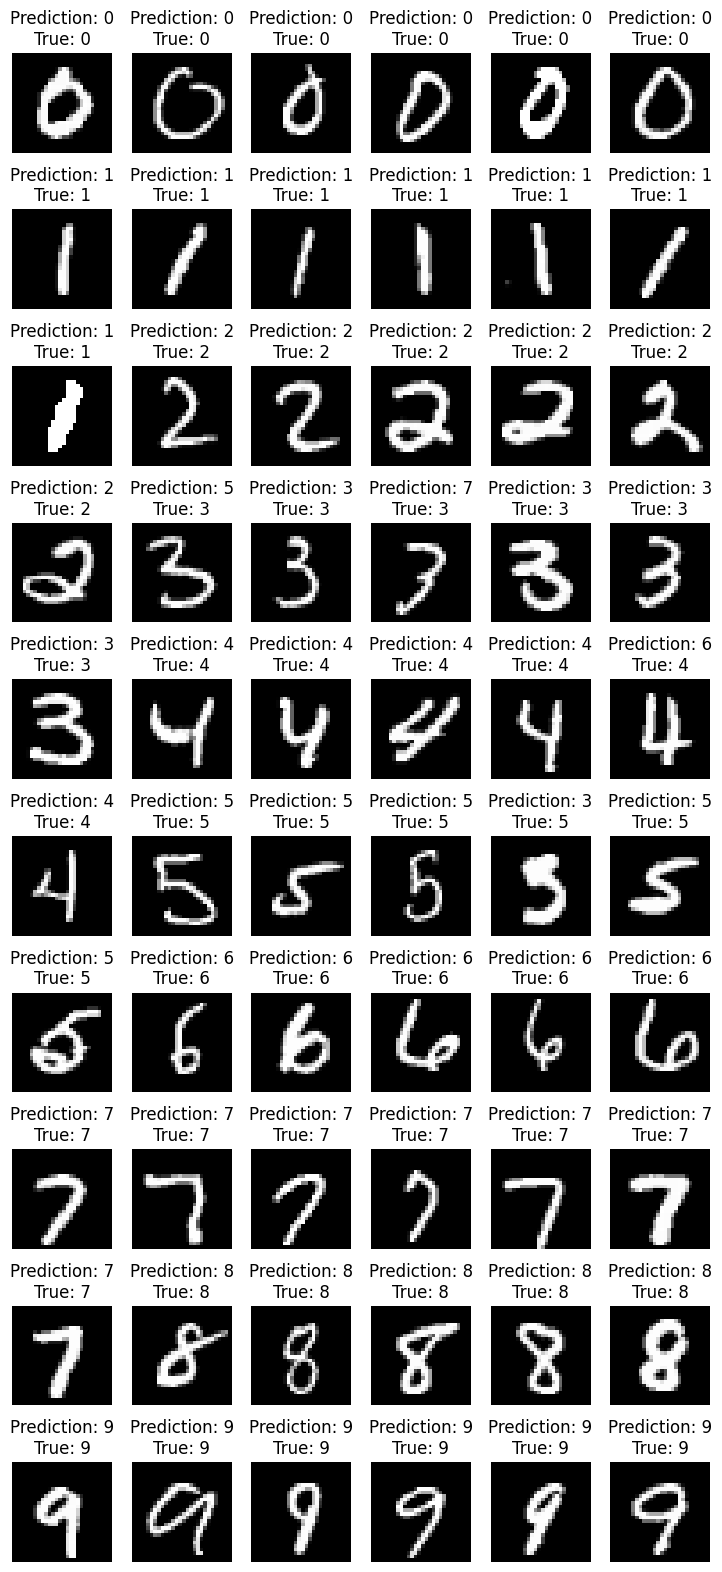

In [22]:
fig, axs = plt.subplots(10, 6, figsize=(9, 20))

for ax, (image, digit) in zip(axs.flatten(), test_dataset[::167]):
    prediction_vector = classifier(image.unsqueeze(0))
    prediction = prediction_vector.argmax().item()

    ax.imshow(image.squeeze().numpy(), cmap="gray")
    ax.set_title(f"Prediction: {prediction}\nTrue: {digit.item()}")
    ax.axis("off")

### 6.2. Calculating the Accuracy

You can calculate the accuracy and error rate on the validation images.

In [23]:
gt_digits = np.array([digit.numpy() for _, digit in test_dataset])
predicted_digits = np.array(
    [
        classifier(image.unsqueeze(0)).argmax().item()
        for image, _digit in test_dataset
    ]
)

accuracy = np.mean(gt_digits == predicted_digits)
print("Accuracy:", accuracy)
print("Error rate:", 1 - accuracy)

Accuracy: 0.9506
Error rate: 0.0494


### 6.3 Visualizing Errors

You can make a failure analysis by visualizing a few images that the model predicted incorrectly.

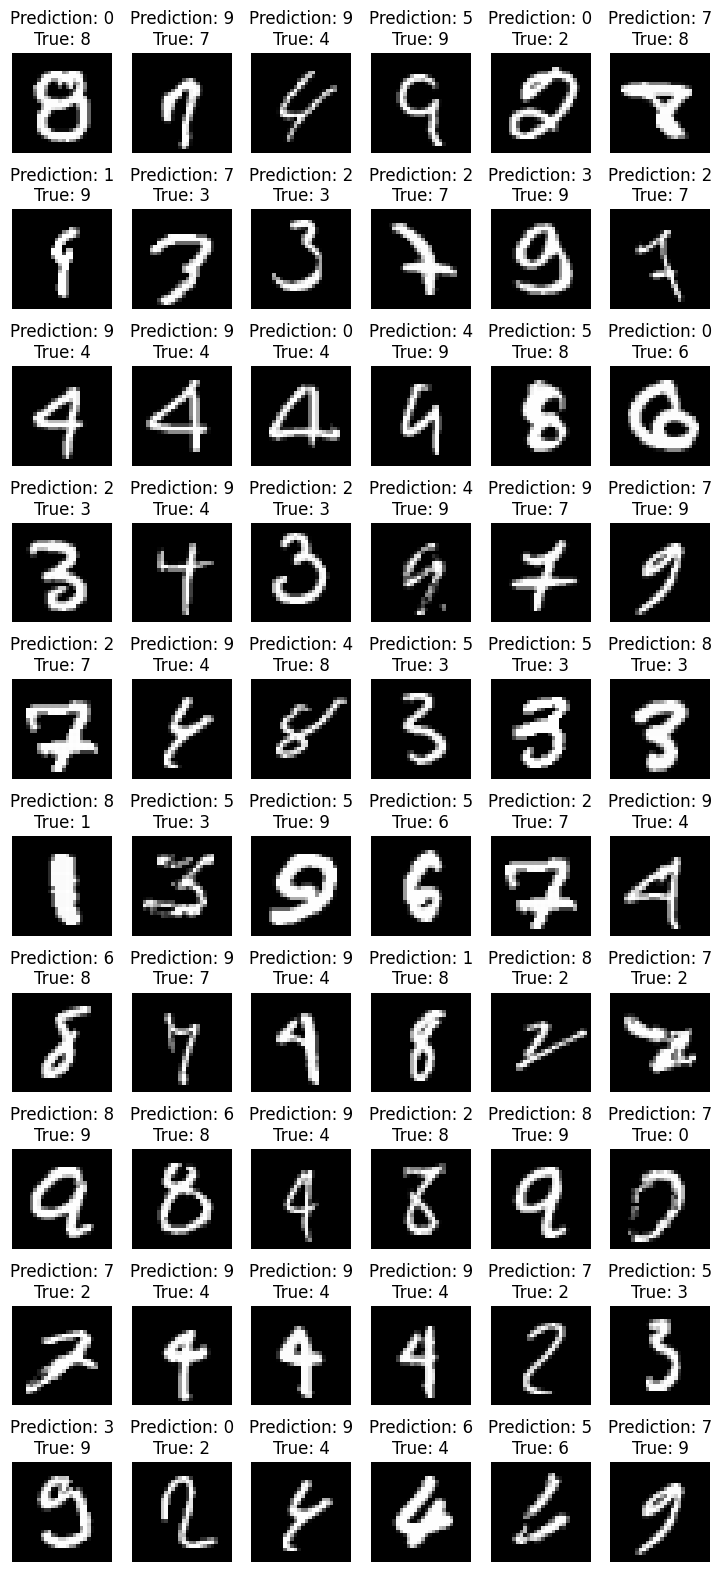

In [24]:
model_is_wrong = predicted_digits != gt_digits
wrong_indices = np.where(model_is_wrong)[0]

fig, axs = plt.subplots(10, 6, figsize=(9, 20))

for ax in axs.flatten():
    i = wrong_indices[np.random.randint(len(wrong_indices))]
    image, digit = test_dataset[i]
    prediction = classifier(image.unsqueeze(0)).argmax().item()
    ax.imshow(image.squeeze().numpy(), cmap="gray")
    ax.set_title(f"Prediction: {prediction}\nTrue: {digit.item()}")
    ax.axis("off")